# California Housing Price Prediction

End-to-end regression pipeline predicting median house value for California districts (1990 census block groups).

**Pipeline:** EDA -> stratified train/test split -> leak-free preprocessing (`ColumnTransformer`) -> model comparison via cross-validation -> hyperparameter tuning -> feature importance -> final hold-out evaluation.

Dataset: `data/housing.csv` (20,640 rows, 10 columns).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset

In [2]:
housing_df = pd.read_csv("data/housing.csv")
print("Shape:", housing_df.shape)
housing_df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploratory Data Analysis

In [3]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing_df.isna().sum().sort_values(ascending=False).head()

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
dtype: int64

In [5]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
housing_df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

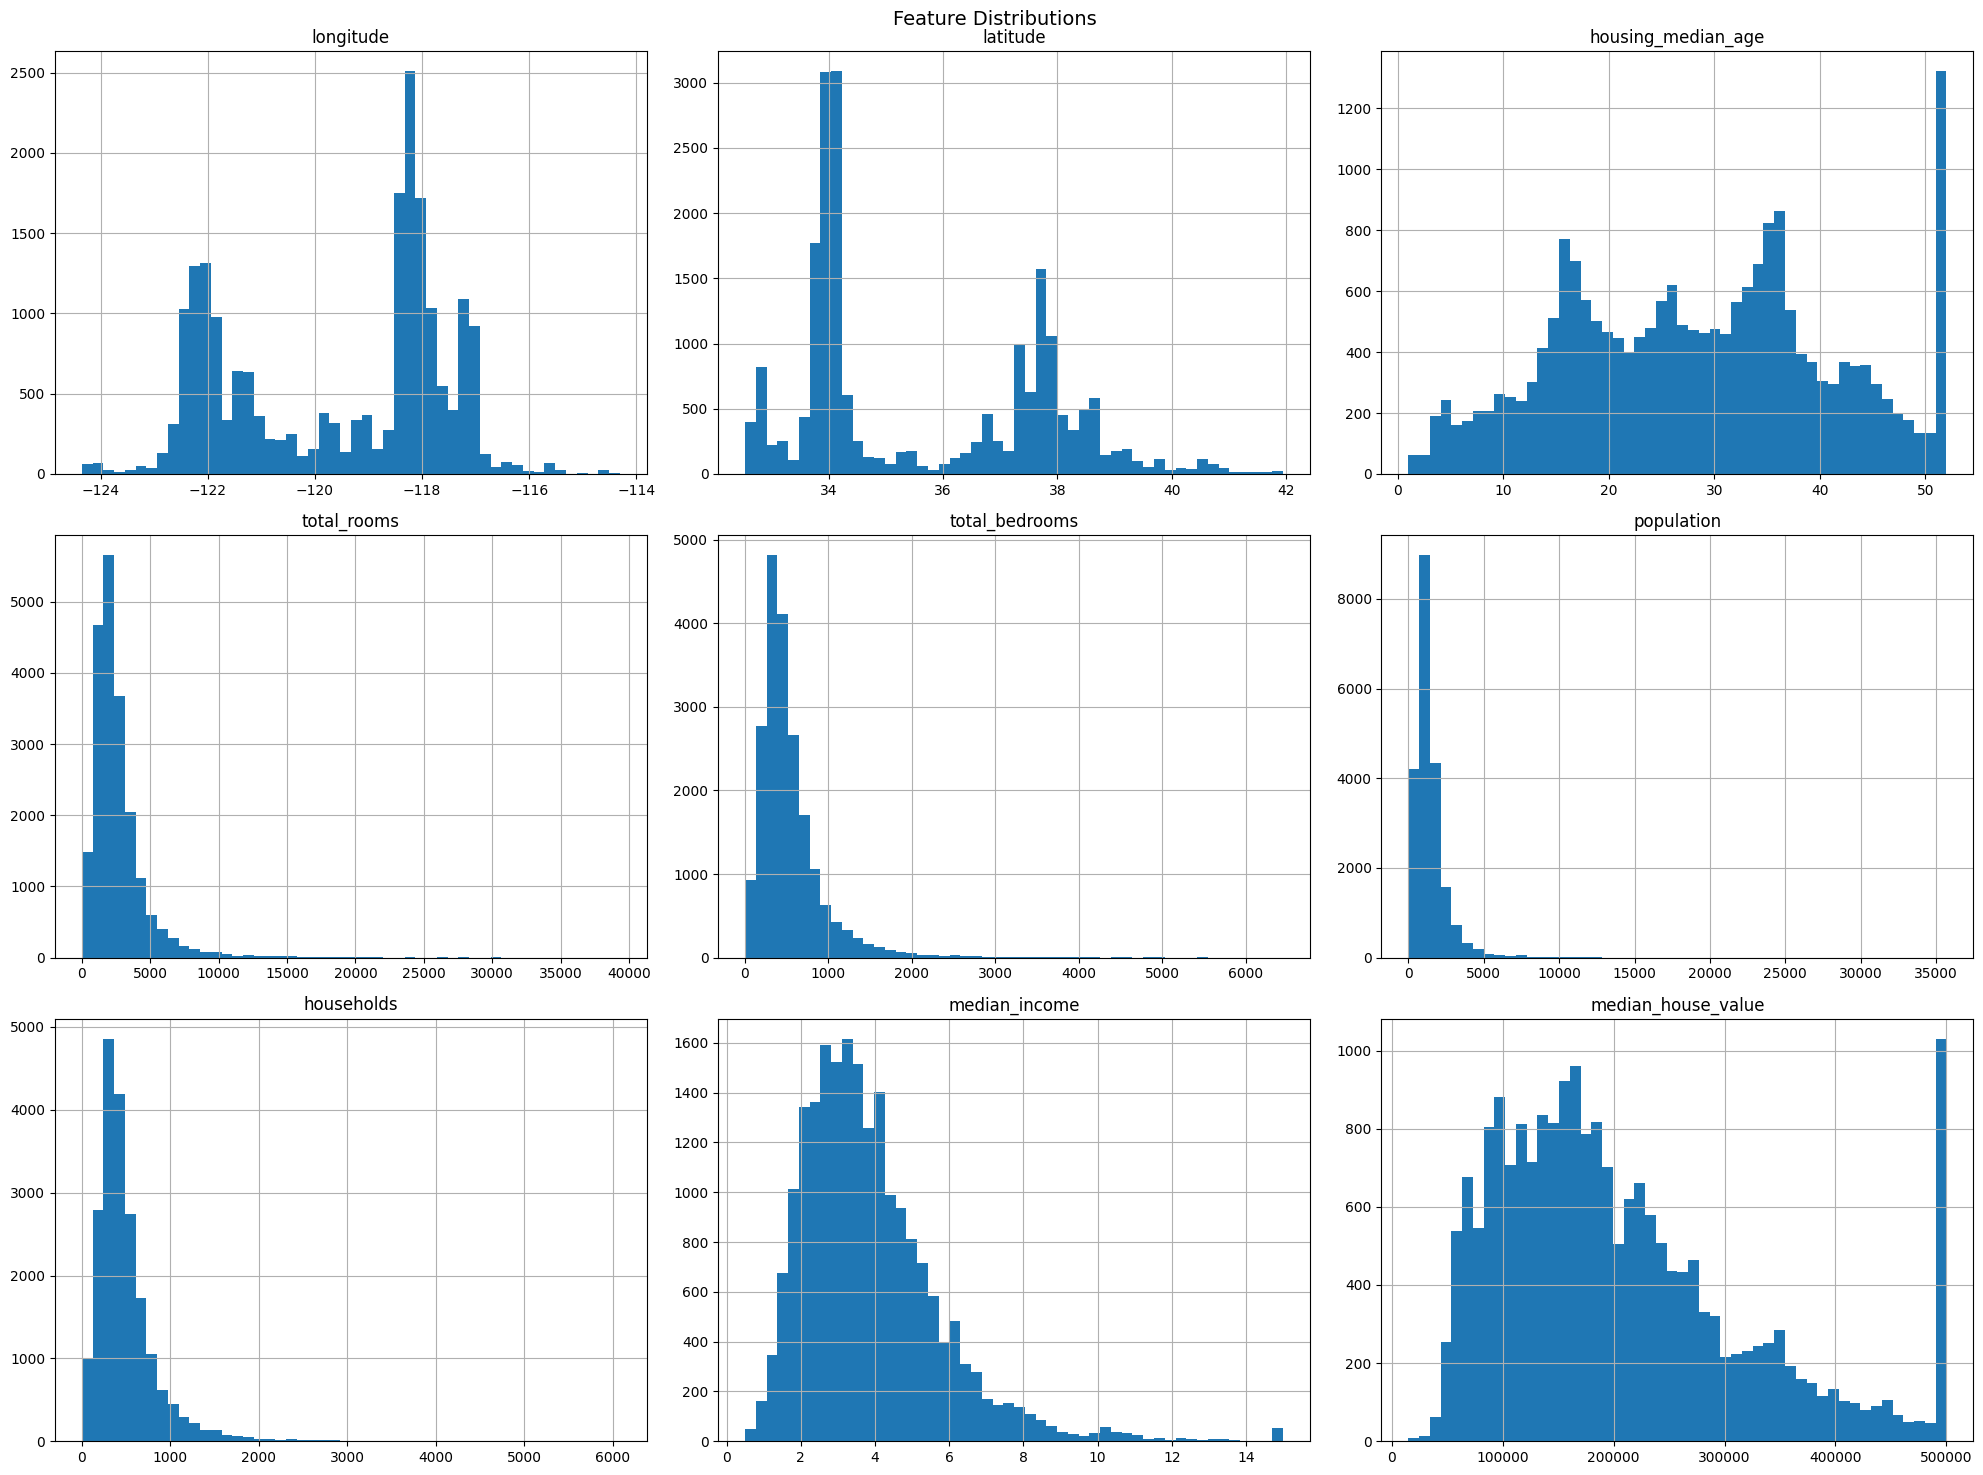

In [7]:
housing_df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- `total_rooms`, `total_bedrooms`, `population`, `households` are heavily right-skewed (district totals, not per-household figures).
- `median_income` is capped/scaled (units of tens of thousands of dollars).
- `median_house_value` is capped at $500,001 — a known artifact of this dataset. Districts at the cap are censored, not genuinely worth exactly that amount. This caps the ceiling of achievable model accuracy and is called out again in the Honest Evaluation Notes at the end.
- `total_bedrooms` has missing values (handled later with median imputation, fit on the training set only).

## 3. Stratified Train/Test Split

`median_income` is the strongest single predictor of house value. A plain random split can, by chance, under/over-represent high-income districts in the test set. We bucket income into strata and use `StratifiedShuffleSplit` so the test set mirrors the full income distribution.

In [8]:
income_cat = pd.cut(
    housing_df["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(housing_df, income_cat))

strat_train_set = housing_df.loc[train_idx].reset_index(drop=True)
strat_test_set = housing_df.loc[test_idx].reset_index(drop=True)

print("Train shape:", strat_train_set.shape)
print("Test shape:", strat_test_set.shape)

# sanity check: income strata proportions should match closely between splits
print("\nFull dataset income strata proportions:")
print(income_cat.value_counts(normalize=True).sort_index())
print("\nTest set income strata proportions:")
print(income_cat.loc[test_idx].value_counts(normalize=True).sort_index())

Train shape: (16512, 10)
Test shape: (4128, 10)

Full dataset income strata proportions:
median_income
1    0.039826
2    0.318847
3    0.350581
4    0.176308
5    0.114438
Name: proportion, dtype: float64

Test set income strata proportions:
median_income
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: proportion, dtype: float64


## 4. Geographic & Correlation Exploration

Exploration is done on the **training set only** to avoid any influence from the test set on modeling decisions (a form of leakage even without touching test labels directly).

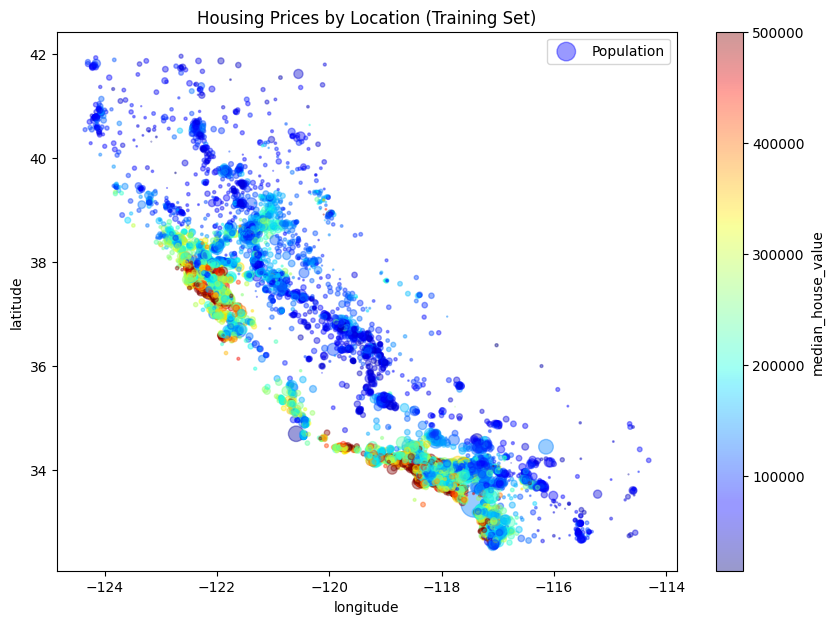

In [9]:
housing_train_explore = strat_train_set.copy()

housing_train_explore.plot(
    kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing_train_explore["population"] / 100, label="Population",
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    figsize=(10, 7),
)
plt.title("Housing Prices by Location (Training Set)")
plt.legend()
plt.show()

Prices are clearly driven by proximity to the coast (the Bay Area and LA/San Diego corridors) and by population density, not purely by latitude/longitude in isolation.

In [10]:
corr_matrix = housing_train_explore.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

## 5. Feature Engineering

Raw district totals (`total_rooms`, `total_bedrooms`, `population`) are more informative as per-household ratios. These are computed as simple row-wise ratios of raw input columns — they don't use the target and don't require fitting, so there's no leakage risk in computing them before the split; they're included here for exploratory correlation only. In the actual pipeline (Section 6) they are generated inside a `FunctionTransformer` so the exact same logic is guaranteed to run identically on train, cross-validation folds, and test.

In [11]:
exploration = housing_train_explore.copy()
exploration["rooms_per_household"] = exploration["total_rooms"] / exploration["households"]
exploration["bedrooms_per_room"] = exploration["total_bedrooms"] / exploration["total_rooms"]
exploration["population_per_household"] = exploration["population"] / exploration["households"]

exploration.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

`bedrooms_per_room` correlates more strongly (negatively) with price than the raw `total_bedrooms`, and `rooms_per_household` is a much stronger positive signal than raw `total_rooms` — engineered ratios carry more signal than the totals they're derived from.

## 6. Preprocessing Pipeline

Built with `ColumnTransformer` + `Pipeline` so that every fitted step (imputer statistics, scaler mean/std, one-hot categories) is learned **only** from the training fold and applied unchanged to validation/test data.

In [12]:
def add_engineered_features(X):
    """X is a numpy array with columns in `num_attribs` order.
    Appends rooms_per_household, population_per_household, bedrooms_per_room.
    """
    rooms_ix = num_attribs.index("total_rooms")
    bedrooms_ix = num_attribs.index("total_bedrooms")
    population_ix = num_attribs.index("population")
    households_ix = num_attribs.index("households")

    rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
    population_per_household = X[:, population_ix] / X[:, households_ix]
    bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]

    return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]


housing_features = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

num_attribs = list(housing_features.drop("ocean_proximity", axis=1).columns)
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", FunctionTransformer(add_engineered_features, feature_names_out="one-to-one")),
    ("std_scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing_features)
print("Prepared shape:", housing_prepared.shape)

Prepared shape: (16512, 16)


## 7. Model Comparison (Cross-Validation)

Baseline: Linear Regression. Then Decision Tree (to illustrate overfitting). Then Random Forest. All CPU-friendly, appropriate for this dataset size (~16.5k training rows, structured tabular data — no case for a neural network here).

In [13]:
def rmse_cv(model, X, y, cv=10):
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=1)
    rmse = np.sqrt(-scores)
    print(f"{model.__class__.__name__}: mean RMSE = {rmse.mean():,.0f}  (std = {rmse.std():,.0f})")
    return rmse

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
_ = rmse_cv(lin_reg, housing_prepared, housing_labels)

LinearRegression: mean RMSE = 69,104  (std = 2,880)


In [15]:
tree_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_reg.fit(housing_prepared, housing_labels)
_ = rmse_cv(tree_reg, housing_prepared, housing_labels)

DecisionTreeRegressor: mean RMSE = 71,630  (std = 2,914)


The single Decision Tree's cross-validated RMSE is worse than Linear Regression despite the tree achieving near-zero training error — a textbook overfitting signature. This is exactly why cross-validation, not training error, is used to compare models.

In [16]:
forest_reg = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
forest_reg.fit(housing_prepared, housing_labels)
_ = rmse_cv(forest_reg, housing_prepared, housing_labels)

RandomForestRegressor: mean RMSE = 50,436  (std = 2,203)


Random Forest gives the best cross-validated RMSE of the three and is carried forward for tuning.

## 8. Hyperparameter Tuning

`RandomizedSearchCV` over a Random Forest, scored on cross-validated RMSE. Randomized search is used over an exhaustive grid because it covers a wider hyperparameter space at a fixed, CPU-friendly compute budget.

In [17]:
from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(50, 300),
    "max_features": randint(2, housing_prepared.shape[1]),
    "max_depth": randint(5, 30),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
random_search.fit(housing_prepared, housing_labels)

print("Best params:", random_search.best_params_)
print(f"Best CV RMSE: {np.sqrt(-random_search.best_score_):,.0f}")

Best params: {'max_depth': 23, 'max_features': 8, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 137}
Best CV RMSE: 50,059


In [18]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results["rmse"] = np.sqrt(-cv_results["mean_test_score"])
cv_results.sort_values("rmse")[["rmse", "params"]].head(5)

,rmse,params
2,50058.923491,"{'max_depth': 23, 'max_features': 8, 'min_samp..."
14,50257.197015,"{'max_depth': 19, 'max_features': 4, 'min_samp..."
9,50282.446535,"{'max_depth': 24, 'max_features': 10, 'min_sam..."
3,50456.429514,"{'max_depth': 25, 'max_features': 5, 'min_samp..."
13,51119.979312,"{'max_depth': 19, 'max_features': 13, 'min_sam..."


## 9. Feature Importance

In [19]:
final_model = random_search.best_estimator_

cat_encoder = full_pipeline.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(cat_encoder.get_feature_names_out(cat_attribs))
extra_attribs = ["rooms_per_household", "population_per_household", "bedrooms_per_room"]
all_attribs = num_attribs + extra_attribs + cat_feature_names

importances = final_model.feature_importances_
importance_df = pd.DataFrame({"feature": all_attribs, "importance": importances})
importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

,feature,importance
0,median_income,0.393015
1,ocean_proximity_INLAND,0.167237
2,population_per_household,0.111085
3,longitude,0.067921
4,latitude,0.061490
5,bedrooms_per_room,0.056949
6,rooms_per_household,0.043263
7,housing_median_age,0.040468
8,total_rooms,0.011711
9,population,0.011680


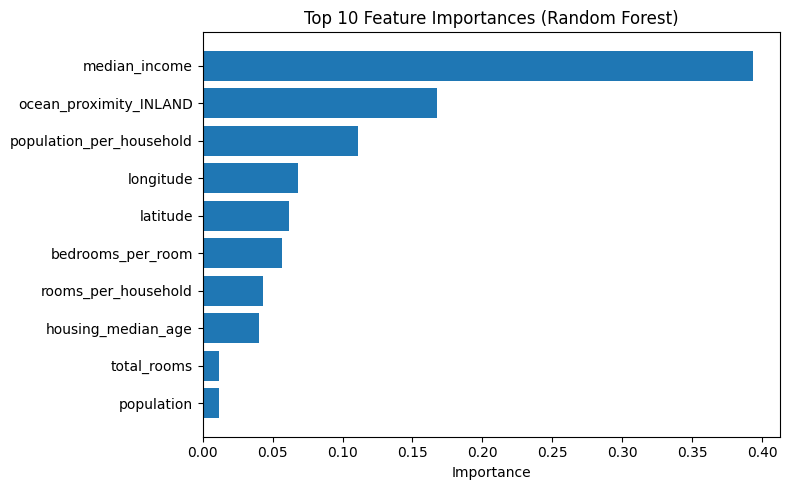

In [20]:
top_n = importance_df.sort_values("importance", ascending=False).head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_n["feature"][::-1], top_n["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

## 10. Final Evaluation on Held-Out Test Set

The test set is transformed with the **already-fitted** `full_pipeline` (no re-fitting) and scored exactly once, at the end.

In [21]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

test_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
test_mae = mean_absolute_error(y_test, final_predictions)
test_r2 = r2_score(y_test, final_predictions)

print(f"Test RMSE: {test_rmse:,.0f}")
print(f"Test MAE:  {test_mae:,.0f}")
print(f"Test R^2:  {test_r2:.4f}")

Test RMSE: 46,867
Test MAE:  31,266
Test R^2:  0.8315


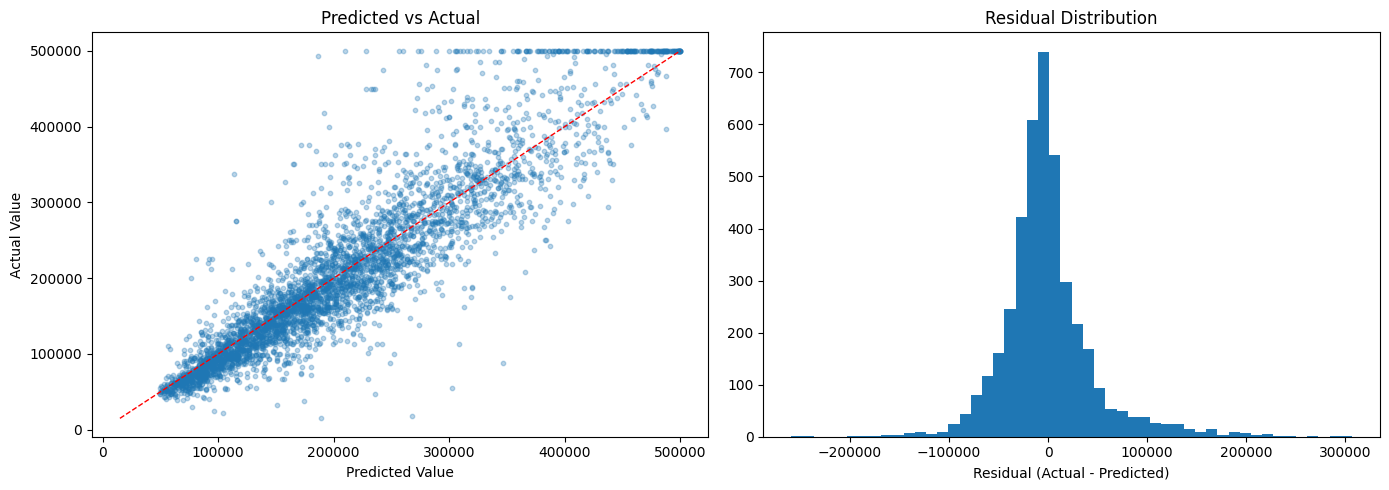

In [22]:
residuals = y_test - final_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(final_predictions, y_test, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1)
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Actual Value")
axes[0].set_title("Predicted vs Actual")

axes[1].hist(residuals, bins=50)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

The predicted-vs-actual plot shows a visible horizontal band of over-predictions around the $500,001 mark — these are the capped/censored districts in the test set (true value unknown beyond the cap), which the model cannot fit correctly by construction. This is a dataset limitation, not a modeling error.